# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)
df = pd.read_csv("../datasets/raw/IndianWeatherRepository.csv")
print("Dataset Loaded Successfully")


Dataset Loaded Successfully


# Numerical Features

In [2]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns
print("Numerical Features:", len(numerical_columns))
numerical_columns

Numerical Features: 30


Index(['latitude', 'longitude', 'last_updated_epoch', 'temperature_celsius',
       'temperature_fahrenheit', 'wind_mph', 'wind_kph', 'wind_degree',
       'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity',
       'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km',
       'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph',
       'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
       'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
       'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index',
       'air_quality_gb-defra-index', 'moon_illumination'],
      dtype='str')

# Correlation Matrix

In [3]:
correlation_matrix = df[numerical_columns].corr()
correlation_matrix

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
latitude,1.000000,0.076073,0.000538,-0.490380,-0.490377,-0.179991,-0.179829,-0.026235,0.186396,0.187593,-0.062708,-0.061577,-0.303735,-0.177401,-0.519100,-0.519091,0.132994,0.137415,0.010608,-0.102985,-0.102954,0.273702,-0.052471,0.223746,0.014896,0.274236,0.283878,0.284087,0.245886,0.000198
longitude,0.076073,1.000000,0.001131,-0.106553,-0.106559,-0.260191,-0.259883,-0.022924,-0.018158,-0.018033,0.042465,0.042097,0.288879,0.135703,-0.086415,-0.086442,-0.099082,-0.092788,0.067044,-0.275154,-0.275102,0.084059,-0.276584,0.030543,0.037465,0.056177,0.044208,0.043621,0.025552,-0.000797
last_updated_epoch,0.000538,0.001131,1.000000,-0.100480,-0.100477,0.110483,0.110415,-0.002884,0.437818,0.438146,-0.135754,-0.134358,-0.482745,-0.286596,-0.177028,-0.177101,0.024022,0.021078,-0.201841,0.233565,0.233606,0.012708,0.464898,0.075932,0.110136,0.045185,0.059255,0.087477,0.071861,0.059107
temperature_celsius,-0.490380,-0.106553,-0.100480,1.000000,0.999990,0.275542,0.275325,0.132329,-0.726573,-0.728150,0.054153,0.053682,0.031131,0.142739,0.983053,0.983048,-0.076158,-0.083607,0.148815,0.225998,0.225925,-0.142655,0.038101,-0.138767,0.061207,-0.249943,-0.222704,-0.210257,-0.159768,0.053337
temperature_fahrenheit,-0.490377,-0.106559,-0.100477,0.999990,1.000000,0.275549,0.275332,0.132321,-0.726576,-0.728153,0.054149,0.053678,0.031109,0.142730,0.983053,0.983054,-0.076158,-0.083607,0.148827,0.226005,0.225931,-0.142667,0.038095,-0.138761,0.061205,-0.249971,-0.222730,-0.210277,-0.159781,0.053327
wind_mph,-0.179991,-0.260191,0.110483,0.275542,0.275549,1.000000,0.999923,0.122754,-0.204819,-0.205045,0.052023,0.051573,-0.117406,0.053109,0.257788,0.257815,0.163245,0.161718,0.041566,0.861805,0.861816,-0.213127,0.312461,-0.188559,-0.010884,-0.228980,-0.223245,-0.273312,-0.264411,-0.009252
wind_kph,-0.179829,-0.259883,0.110415,0.275325,0.275332,0.999923,1.000000,0.122158,-0.204831,-0.205056,0.052153,0.051699,-0.117020,0.053377,0.257594,0.257622,0.163060,0.161552,0.041663,0.861335,0.861338,-0.213081,0.312374,-0.188507,-0.010769,-0.229049,-0.223281,-0.273468,-0.264563,-0.009400
wind_degree,-0.026235,-0.022924,-0.002884,0.132329,0.132321,0.122754,0.122158,1.000000,-0.151059,-0.150756,0.006291,0.006468,-0.097724,-0.036157,0.118569,0.118586,0.102528,0.103948,0.068966,0.091537,0.091543,-0.021376,0.042870,-0.054543,-0.023004,0.012885,0.017645,-0.017557,-0.046009,-0.006007
pressure_mb,0.186396,-0.018158,0.437818,-0.726573,-0.726576,-0.204819,-0.204831,-0.151059,1.000000,0.998303,-0.157727,-0.156365,-0.245403,-0.320283,-0.751413,-0.751451,-0.000531,-0.000174,-0.157738,-0.104119,-0.104053,0.146337,0.175638,0.178808,0.013849,0.260459,0.249557,0.282799,0.251501,-0.042975
pressure_in,0.187593,-0.018033,0.438146,-0.728150,-0.728153,-0.205045,-0.205056,-0.150756,0.998303,1.000000,-0.157883,-0.156525,-0.247085,-0.320790,-0.753123,-0.753162,0.001885,0.002287,-0.158604,-0.104708,-0.104642,0.146330,0.175642,0.178441,0.013152,0.260902,0.249883,0.283358,0.251985,-0.042835


# Full Correlation Heatmap

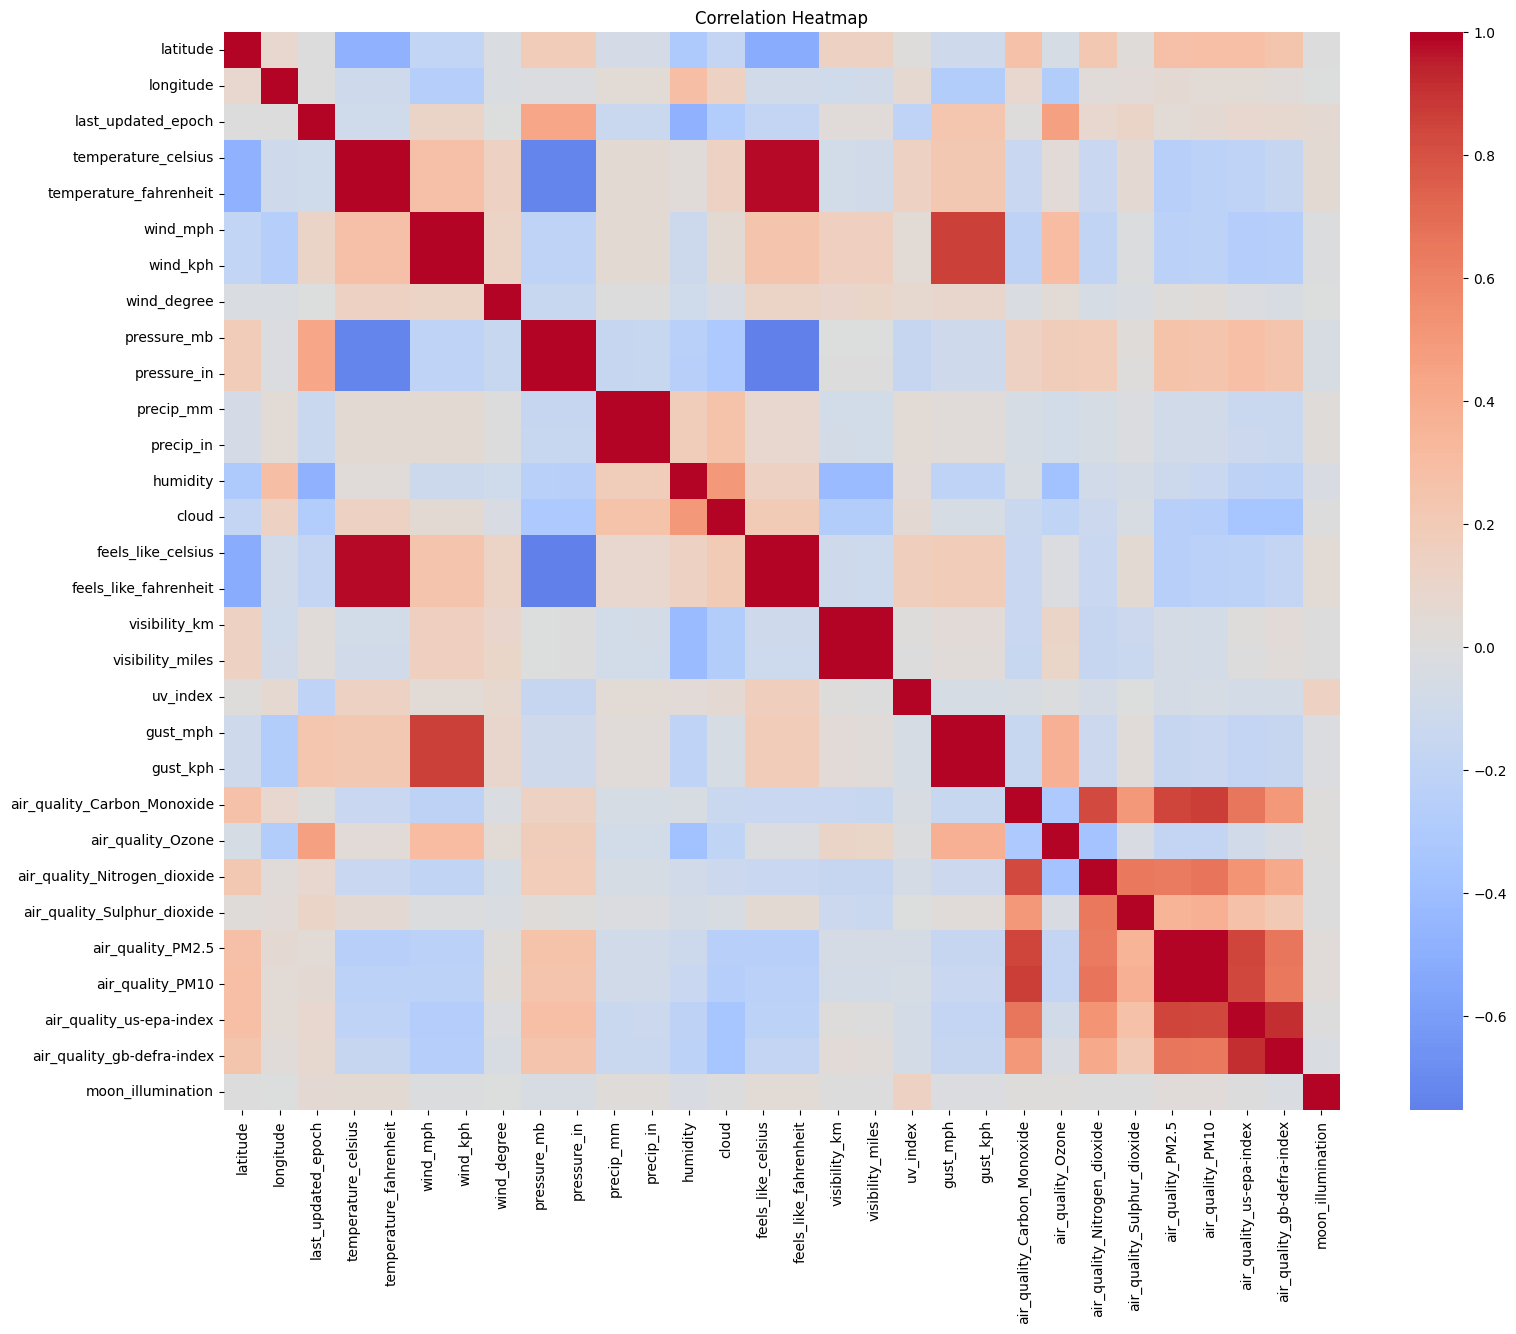

In [4]:
plt.figure(figsize=(18,14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

# Strong Positive Correlations

In [5]:
strong_positive = []

for col1 in correlation_matrix.columns:
    for col2 in correlation_matrix.columns:
        if col1 != col2:
            corr = correlation_matrix.loc[col1, col2]

            if corr > 0.80:
                strong_positive.append(
                    [col1, col2, round(corr,3)]
                )

strong_positive_df = pd.DataFrame(
    strong_positive,
    columns=["Feature1","Feature2","Correlation"]
)

strong_positive_df.drop_duplicates()


,Feature1,Feature2,Correlation
0,temperature_celsius,temperature_fahrenheit,1.000
1,temperature_celsius,feels_like_celsius,0.983
2,temperature_celsius,feels_like_fahrenheit,0.983
3,temperature_fahrenheit,temperature_celsius,1.000
4,temperature_fahrenheit,feels_like_celsius,0.983
5,temperature_fahrenheit,feels_like_fahrenheit,0.983
6,wind_mph,wind_kph,1.000
7,wind_mph,gust_mph,0.862
8,wind_mph,gust_kph,0.862
9,wind_kph,wind_mph,1.000


# Strong Negative Correlations

In [6]:
strong_negative = []

for col1 in correlation_matrix.columns:
    for col2 in correlation_matrix.columns:
        if col1 != col2:

            corr = correlation_matrix.loc[col1,col2]

            if corr < -0.50:
                strong_negative.append(
                    [col1,col2,round(corr,3)]
                )
strong_negative_df = pd.DataFrame(
    strong_negative,
    columns=["Feature1","Feature2","Correlation"]
)

strong_negative_df.drop_duplicates()


,Feature1,Feature2,Correlation
0,latitude,feels_like_celsius,-0.519
1,latitude,feels_like_fahrenheit,-0.519
2,temperature_celsius,pressure_mb,-0.727
3,temperature_celsius,pressure_in,-0.728
4,temperature_fahrenheit,pressure_mb,-0.727
5,temperature_fahrenheit,pressure_in,-0.728
6,pressure_mb,temperature_celsius,-0.727
7,pressure_mb,temperature_fahrenheit,-0.727
8,pressure_mb,feels_like_celsius,-0.751
9,pressure_mb,feels_like_fahrenheit,-0.751


# Rainfall Correlations# 

In [7]:
rainfall_corr = correlation_matrix["precip_mm"]

rainfall_corr.sort_values(
    ascending=False
)


precip_mm                       1.000000
precip_in                       0.999224
cloud                           0.267060
humidity                        0.174144
feels_like_fahrenheit           0.076720
feels_like_celsius              0.076704
temperature_celsius             0.054153
temperature_fahrenheit          0.054149
wind_kph                        0.052153
wind_mph                        0.052023
uv_index                        0.047931
longitude                       0.042465
gust_kph                        0.027230
gust_mph                        0.027227
moon_illumination               0.014724
wind_degree                     0.006291
air_quality_Sulphur_dioxide    -0.014926
air_quality_Nitrogen_dioxide   -0.050141
air_quality_Carbon_Monoxide    -0.050391
latitude                       -0.062708
visibility_km                  -0.076036
air_quality_Ozone              -0.078021
visibility_miles               -0.081051
air_quality_PM2.5              -0.087764
air_quality_PM10

# Heatwave Correlations

In [8]:
heatwave_corr = correlation_matrix[
    "feels_like_celsius"
]
heatwave_corr.sort_values(
    ascending=False
)

feels_like_celsius              1.000000
feels_like_fahrenheit           0.999991
temperature_celsius             0.983053
temperature_fahrenheit          0.983053
wind_mph                        0.257788
wind_kph                        0.257594
cloud                           0.200925
gust_mph                        0.189887
gust_kph                        0.189814
uv_index                        0.168632
humidity                        0.134282
wind_degree                     0.118569
precip_mm                       0.076704
precip_in                       0.075921
air_quality_Sulphur_dioxide     0.053491
moon_illumination               0.041694
air_quality_Ozone              -0.015161
longitude                      -0.086415
visibility_km                  -0.106898
visibility_miles               -0.114843
air_quality_Carbon_Monoxide    -0.139718
air_quality_Nitrogen_dioxide   -0.141084
air_quality_gb-defra-index     -0.176123
last_updated_epoch             -0.177028
air_quality_us-e

# Feature Redundancy Assessment

In [9]:
redundant_features = [
    "temperature_fahrenheit",
    "wind_mph",
    "pressure_in",
    "precip_in",
    "visibility_miles",
    "gust_mph"
]
df[redundant_features].head()

,temperature_fahrenheit,wind_mph,pressure_in,precip_in,visibility_miles,gust_mph
0,81.5,12.8,29.77,0.0,6,14.8
1,81.5,9.6,29.78,0.0,6,11.2
2,79.3,11.4,29.78,0.0,6,13.2
3,78.1,10.5,29.80,0.0,6,13.0
4,81.0,10.1,29.79,0.0,6,11.6


# Correlation Insights Report

In [10]:
print("""
CORRELATION ANALYSIS REPORT
1. Strong positive correlations identified.
2. Strong negative correlations identified.
3. Rainfall predictor relationships analyzed.
4. Heatwave predictor relationships analyzed.
5. Redundant features identified.
6. Multicollinearity assessment completed.
7. Dataset is ready for preprocessing.
8. Candidate features finalized for:
   - Clustering
   - Anomaly Detection
   - Rainfall Prediction
   - Heatwave Prediction
""")


CORRELATION ANALYSIS REPORT
1. Strong positive correlations identified.
2. Strong negative correlations identified.
3. Rainfall predictor relationships analyzed.
4. Heatwave predictor relationships analyzed.
5. Redundant features identified.
6. Multicollinearity assessment completed.
7. Dataset is ready for preprocessing.
8. Candidate features finalized for:
   - Clustering
   - Anomaly Detection
   - Rainfall Prediction
   - Heatwave Prediction

